In [1]:
import torch
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# Image Preprocessing

transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
# Loading Dataset

train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transform, 
    download=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

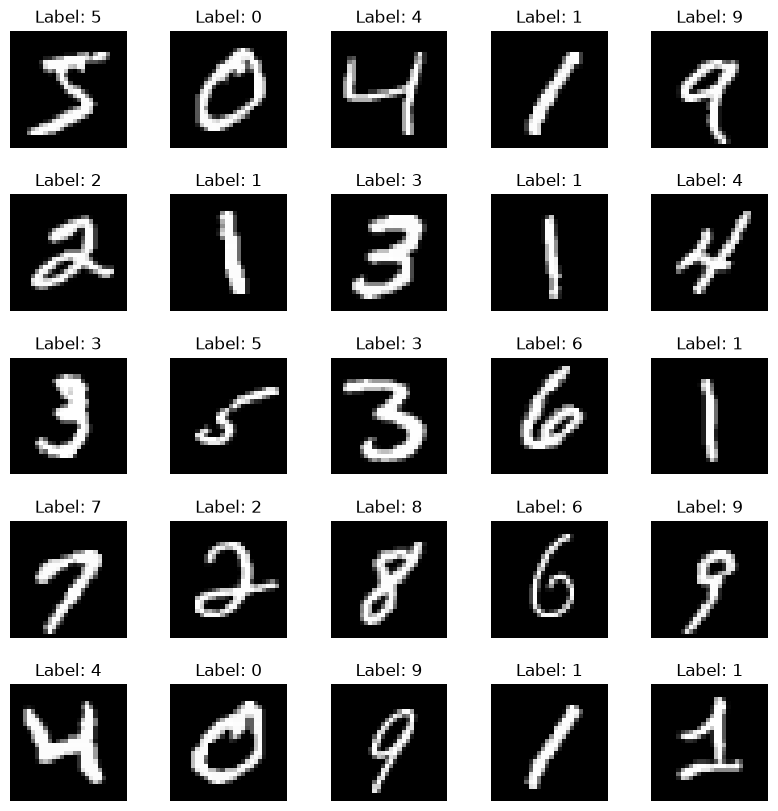

In [4]:
# Plotting the first 25 images from the training dataset

def show_images(images, labels):
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.subplots_adjust(hspace=0.4)
    plt.show()

image_data = [train_dataset[i][0] for i in range(25)]
image_labels = [train_dataset[i][1] for i in range(25)]
show_images(image_data, image_labels)

In [5]:
# Loading data into DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=1000, 
    shuffle=False
)


In [9]:
images[0].size()

torch.Size([1, 28, 28])

In [6]:
images, labels = next(iter(train_loader))
print(f"Images batch shape: {images.shape}")  # [Batch Size, Channels, Height, Width]
print(f"Labels batch shape: {labels.shape}")  # [Batch Size]

Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [7]:
# Training
from ClassifierModel import ImageClassifier

print(f"Training on {"GPU" if torch.cuda.is_available() else "CPU"}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ImageClassifier().to(device)
optimizer = Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss() # CrossEntropyLoss applies softmax internally.

for epoch in range(100):
    model.train()
    for image, label in train_loader:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad() 
        output = model(image)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Training Loss: {loss.item()}")
        model.eval()
        test_loss = 0
        num_correct = 0
        total = 0
        with torch.no_grad():
            for image, label in test_loader:
                image, label = image.to(device), label.to(device)
                output = model(image)
                test_loss += loss_fn(output, label).item()
                pred = output.argmax(dim=1, keepdim=True)
                total += label.size(0)
                num_correct += (pred.squeeze() == label).sum().item()
            accuracy = 100 * num_correct / total
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%")



Training on GPU
Epoch 0, Training Loss: 0.21769234538078308
Test Loss: 0.4751, Test Accuracy: 98.61%
Epoch 10, Training Loss: 0.012960703112185001
Test Loss: 0.5675, Test Accuracy: 98.36%
Epoch 20, Training Loss: 7.341081800404936e-05
Test Loss: 0.3801, Test Accuracy: 99.26%
Epoch 30, Training Loss: 0.00048087764298543334
Test Loss: 0.3980, Test Accuracy: 99.36%
Epoch 40, Training Loss: 6.556444418492902e-07
Test Loss: 0.5287, Test Accuracy: 99.27%
Epoch 50, Training Loss: 0.0
Test Loss: 0.5727, Test Accuracy: 99.29%
Epoch 60, Training Loss: 5.8519644881016575e-06
Test Loss: 0.6320, Test Accuracy: 99.16%
Epoch 70, Training Loss: 0.0005957628600299358
Test Loss: 0.6988, Test Accuracy: 99.27%
Epoch 80, Training Loss: 2.976365294671268e-06
Test Loss: 0.8630, Test Accuracy: 99.25%
Epoch 90, Training Loss: 9.685739854603526e-08
Test Loss: 0.7633, Test Accuracy: 99.34%


In [10]:
# Saving the model

torch.save(model.state_dict(), 'mnist_model.pt')

In [15]:
output = model(images[0].unsqueeze(0).to(device))
pred = output.argmax(dim=1).item()
pred

8